**********************Exploratory Data Analysis**********************

In [1]:
import pandas as pd

# load the dataset
df = pd.read_csv("ddinter_downloads_code_V.csv")
df.head(10)

,DDInterID_A,Drug_A,DDInterID_B,Drug_B,Level
0,DDInter1,Abacavir,DDInter424,Cobicistat,Moderate
1,DDInter690,Ethanol,DDInter1,Abacavir,Minor
2,DDInter270,Calcium acetate,DDInter582,Dolutegravir,Major
3,DDInter1019,Lamivudine,DDInter424,Cobicistat,Moderate
4,DDInter488,Deferasirox,DDInter582,Dolutegravir,Minor
5,DDInter582,Dolutegravir,DDInter1785,Tetraferric tricitrate decahydrate,Major
6,DDInter582,Dolutegravir,DDInter1113,Magnesium carbonate,Major
7,DDInter1120,Magnesium sulfate,DDInter582,Dolutegravir,Major
8,DDInter1019,Lamivudine,DDInter1123,Mannitol,Moderate
9,DDInter1019,Lamivudine,DDInter1703,Sorbitol,Moderate


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (12024, 5)

Columns:
 Index(['DDInterID_A', 'Drug_A', 'DDInterID_B', 'Drug_B', 'Level'], dtype='object')

Data Types:
 DDInterID_A    object
Drug_A         object
DDInterID_B    object
Drug_B         object
Level          object
dtype: object


********************Are there any Missing Values?********************

In [3]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 DDInterID_A    0
Drug_A         0
DDInterID_B    0
Drug_B         0
Level          0
dtype: int64


***********************Are there any Duplicates?***********************

In [4]:
# Exact duplicates
exact_dups = df.duplicated().sum()
print("\nExact duplicates:", exact_dups)

# Symmetric duplicates (A,B) == (B,A)
df['pair_sorted'] = df.apply(
    lambda x: tuple(sorted([x['Drug_A'], x['Drug_B']])), axis=1
)

symmetric_dups = df.duplicated('pair_sorted').sum()
print("Symmetric duplicates:", symmetric_dups)


Exact duplicates: 0
Symmetric duplicates: 0


************************How many Unique Drugs do we have?************************

In [5]:
unique_drugs = set(df['Drug_A']).union(set(df['Drug_B']))
print("\nNumber of unique drugs:", len(unique_drugs))


Number of unique drugs: 1692


*********************What is the Class Distribution?*********************

In [6]:
level_counts = df['Level'].value_counts()
level_percent = df['Level'].value_counts(normalize=True) * 100

print("\nClass Distribution:\n", level_counts)
print("\nClass Percentage:\n", level_percent)


Class Distribution:
 Level
Moderate    6451
Major       2924
Unknown     2362
Minor        287
Name: count, dtype: int64

Class Percentage:
 Level
Moderate    53.651031
Major       24.318031
Unknown     19.644045
Minor        2.386893
Name: proportion, dtype: float64


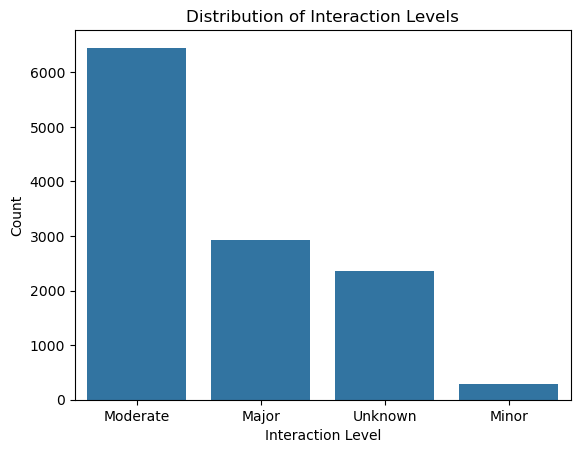

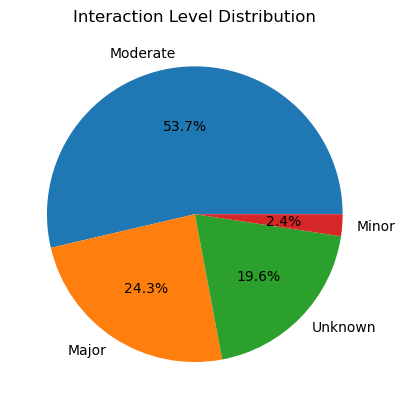

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.countplot(x='Level', data=df, order=level_counts.index)
plt.title("Distribution of Interaction Levels")
plt.xlabel("Interaction Level")
plt.ylabel("Count")
plt.show()

# Pie chart
plt.figure()
plt.pie(level_counts, labels=level_counts.index, autopct='%1.1f%%')
plt.title("Interaction Level Distribution")
plt.show()

**********************What are the Most Frequent Drugs?**********************


Top Drugs in Drug_A:
 Drug_A
Folic acid              425
Prednisolone            402
Promethazine            319
Ethanol                 223
Deferasirox             180
Tolbutamide             179
Ibritumomab tiuxetan    176
Tositumomab (I-131)     175
Leucovorin              157
Tositumomab             151
Name: count, dtype: int64

Top Drugs in Drug_B:
 Drug_B
Promethazine      513
Prednisolone      349
Deferasirox       338
Cobicistat        327
Macimorelin       316
Iopamidol         312
Tolbutamide       282
Iohexol           265
Ethanol           248
Acetylcysteine    244
Name: count, dtype: int64


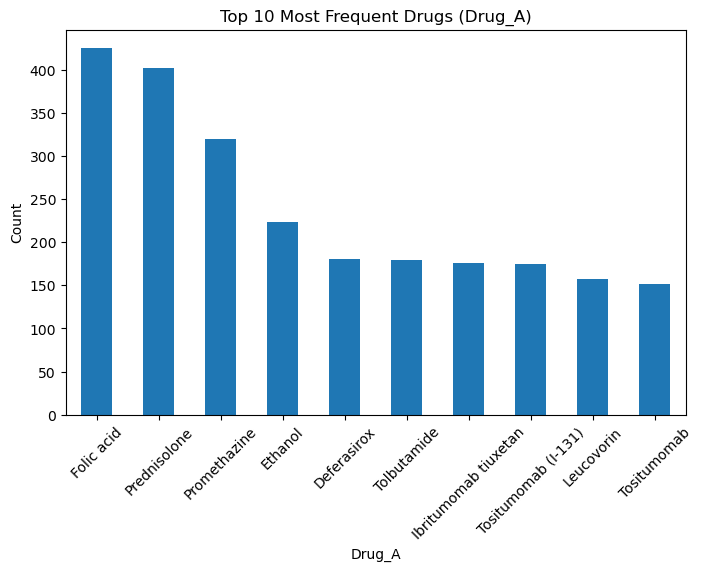

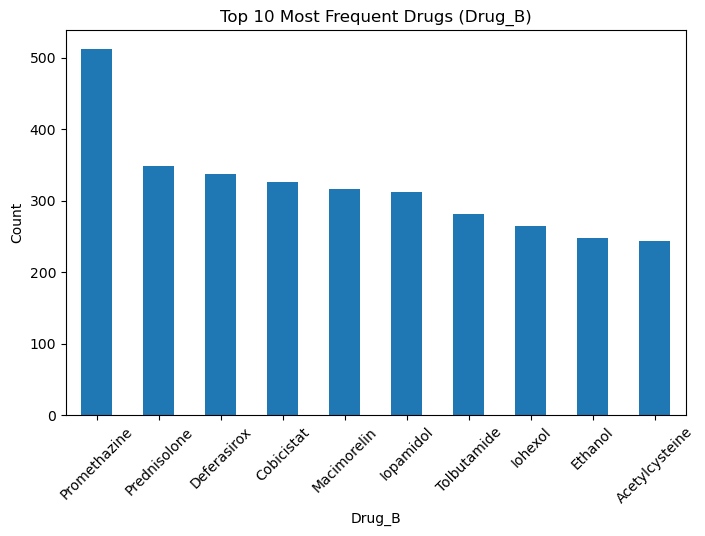

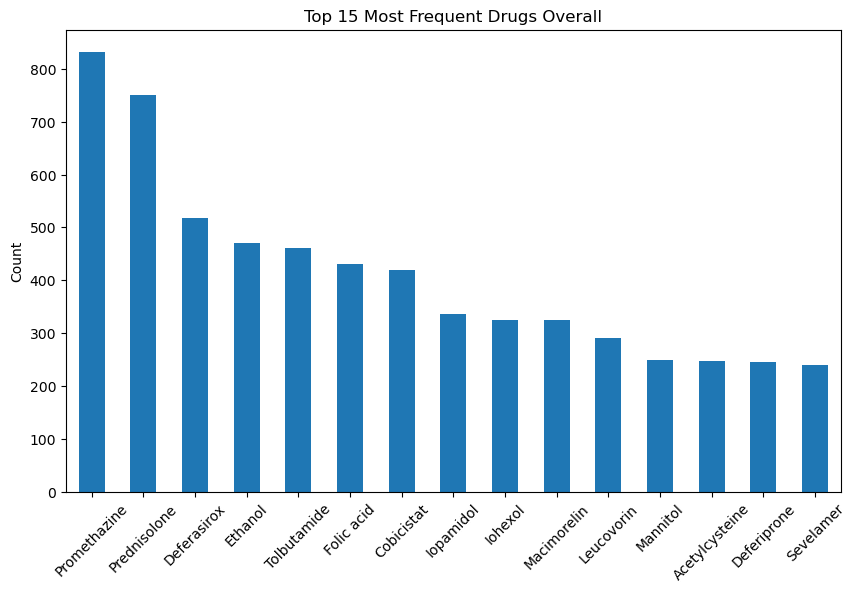

In [8]:
# Most Frequent Drugs

top_A = df['Drug_A'].value_counts().head(10)
top_B = df['Drug_B'].value_counts().head(10)

print("\nTop Drugs in Drug_A:\n", top_A)
print("\nTop Drugs in Drug_B:\n", top_B)

# Plot top Drug_A
plt.figure(figsize=(8,5))
top_A.plot(kind='bar')
plt.title("Top 10 Most Frequent Drugs (Drug_A)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Plot top Drug_B
plt.figure(figsize=(8,5))
top_B.plot(kind='bar')
plt.title("Top 10 Most Frequent Drugs (Drug_B)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Combined Drug Frequency

all_drugs = pd.concat([df['Drug_A'], df['Drug_B']])
top_drugs = all_drugs.value_counts().head(15)

plt.figure(figsize=(10,6))
top_drugs.plot(kind='bar')
plt.title("Top 15 Most Frequent Drugs Overall")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

******************Network Graph Analysis******************


Number of nodes (drugs): 1692
Number of edges (interactions): 12024

Top 10 Most Connected Drugs:
Promethazine: 832
Prednisolone: 751
Deferasirox: 518
Ethanol: 471
Tolbutamide: 461
Folic acid: 430
Cobicistat: 420
Iopamidol: 337
Macimorelin: 325
Iohexol: 325


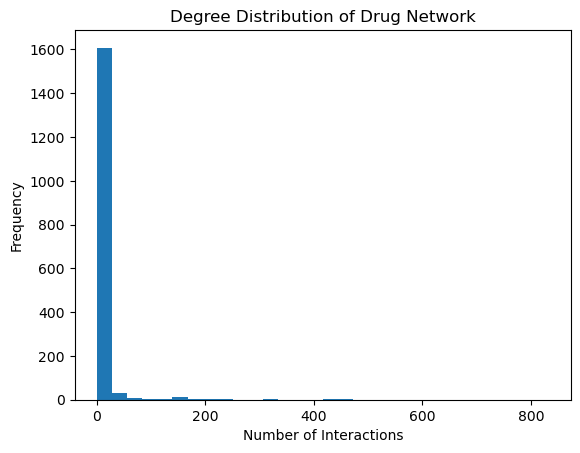

In [9]:
import networkx as nx

# Create graph
G = nx.Graph()

# Add edges
for _, row in df.iterrows():
    G.add_edge(row['Drug_A'], row['Drug_B'], weight=row['Level'])

print("\nNumber of nodes (drugs):", G.number_of_nodes())
print("Number of edges (interactions):", G.number_of_edges())

# Degree analysis (most connected drugs)
degree_dict = dict(G.degree())
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Most Connected Drugs:")
for drug, deg in top_degree:
    print(f"{drug}: {deg}")

# Plot degree distribution
degrees = list(degree_dict.values())

plt.figure()
plt.hist(degrees, bins=30)
plt.title("Degree Distribution of Drug Network")
plt.xlabel("Number of Interactions")
plt.ylabel("Frequency")
plt.show()

*********************What is the Severity Distribution by Drugs?*********************

In [10]:
severity_by_drug = df.groupby('Drug_A')['Level'].value_counts().unstack().fillna(0)

print("\nSeverity distribution per drug (sample):\n", severity_by_drug.head())


Severity distribution per drug (sample):
 Level        Major  Minor  Moderate  Unknown
Drug_A                                      
Abacavir       0.0    0.0       1.0      2.0
Abarelix       1.0    0.0       1.0      0.0
Abciximab      4.0    0.0       0.0      0.0
Abiraterone    1.0    1.0       0.0      0.0
Acarbose       0.0    0.0       4.0      2.0


************************The Dataset only includes positive cases (interaction),************************
***************We will Generate random negative cases (no interaction) and verify them***************

In [11]:
# Drop the id columns
df = df.drop(columns=['DDInterID_A'])
df = df.drop(columns=['DDInterID_B'])

In [12]:
df.head()

,Drug_A,Drug_B,Level,pair_sorted
0,Abacavir,Cobicistat,Moderate,"(Abacavir, Cobicistat)"
1,Ethanol,Abacavir,Minor,"(Abacavir, Ethanol)"
2,Calcium acetate,Dolutegravir,Major,"(Calcium acetate, Dolutegravir)"
3,Lamivudine,Cobicistat,Moderate,"(Cobicistat, Lamivudine)"
4,Deferasirox,Dolutegravir,Minor,"(Deferasirox, Dolutegravir)"


In [14]:
# Generate negatives

import random

# positive pairs
positive_pairs = set(df['pair_sorted'])

# All drugs
drugs = list(set(df['Drug_A']).union(set(df['Drug_B'])))

# number of positives
n_pos = len(positive_pairs)

# negatives (Balanced)
negative_pairs = set()

while len(negative_pairs) < n_pos:
    d1, d2 = random.sample(drugs, 2)
    pair = tuple(sorted([d1, d2]))
    
    if pair not in positive_pairs:
        negative_pairs.add(pair)

# negative DataFrame
neg_df = pd.DataFrame(list(negative_pairs), columns=['Drug_A', 'Drug_B'])
neg_df['Level'] = 'No Interaction'

# Verify the negative from a large comprehensive dataset

# Load the full interaction dataset
full_df = pd.read_csv("db_drug_interactions.csv")

# Create sorted pairs for consistent comparison
full_df['pair_sorted'] = full_df.apply(
    lambda row: tuple(sorted([row['Drug 1'], row['Drug 2']])), axis=1
)

# Convert to set for fast lookup
full_pairs = set(full_df['pair_sorted'])

# Add sorted pairs to negative dataframe
neg_df['pair_sorted'] = neg_df.apply(
    lambda row: tuple(sorted([row['Drug_A'], row['Drug_B']])), axis=1
)

# Count before filtering
before_count = len(neg_df)

# Remove negatives that actually exist in real dataset
neg_df = neg_df[~neg_df['pair_sorted'].isin(full_pairs)]

# Count after filtering
after_count = len(neg_df)

# Number of deleted pairs
deleted_pairs = before_count - after_count

print(f"Number of deleted negative pairs: {deleted_pairs}")

# Drop helper column
neg_df = neg_df.drop(columns=['pair_sorted'])

Number of deleted negative pairs: 970


In [15]:
# positive DataFrame
pos_df = df[['Drug_A', 'Drug_B', 'Level']].copy()

# combine
final_df = pd.concat([pos_df, neg_df], ignore_index=True)

In [20]:
final_df.shape

(23078, 3)

In [21]:
final_df.head()

,Drug_A,Drug_B,Level
0,Abacavir,Cobicistat,Moderate
1,Ethanol,Abacavir,Minor
2,Calcium acetate,Dolutegravir,Major
3,Lamivudine,Cobicistat,Moderate
4,Deferasirox,Dolutegravir,Minor


In [22]:
level_counts = final_df['Level'].value_counts()
level_percent = final_df['Level'].value_counts(normalize=True) * 100

print("\nClass Distribution:\n", level_counts)
print("\nClass Percentage:\n", level_percent)


Class Distribution:
 Level
No Interaction    11054
Moderate           6451
Major              2924
Unknown            2362
Minor               287
Name: count, dtype: int64

Class Percentage:
 Level
No Interaction    47.898431
Moderate          27.953029
Major             12.670075
Unknown           10.234856
Minor              1.243609
Name: proportion, dtype: float64


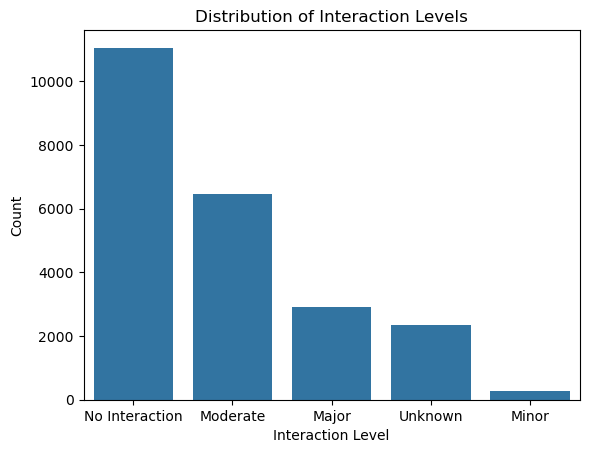

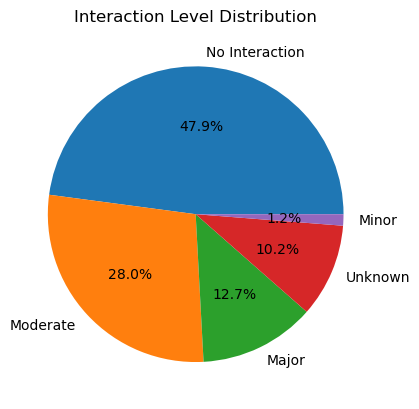

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.countplot(x='Level', data=final_df, order=level_counts.index)
plt.title("Distribution of Interaction Levels")
plt.xlabel("Interaction Level")
plt.ylabel("Count")
plt.show()

# Pie chart
plt.figure()
plt.pie(level_counts, labels=level_counts.index, autopct='%1.1f%%')
plt.title("Interaction Level Distribution")
plt.show()

In [25]:
# shuffle data
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
# save final_df in a new csv file with the name (DDinter_with_negatives)
final_df.to_csv("DDinter_with_negatives.csv", index=False)

In [5]:
import pandas as pd

# load the dataset
df2 = pd.read_csv("DDinter_with_negatives.csv")
df2.head(10)

,Drug_A,Drug_B,Level
0,Sevelamer,Doxorubicin,Unknown
1,Flecainide,Acetylcysteine,Unknown
2,Levobupivacaine,Cobicistat,Moderate
3,Exemestane,Raloxifene,No Interaction
4,Brexpiprazole,Ticagrelor,No Interaction
5,Chlorpromazine,Magnesium carbonate,Minor
6,Esmolol,Sodium bicarbonate,No Interaction
7,Prednisolone,Zinc sulfate,Minor
8,Clofarabine,Phenindamine,No Interaction
9,Pamidronic acid,Acetylcysteine,Unknown


*******************We notice there are no outliers*******************


📊 Plotting distribution of rare drugs...
Number of rare drugs (frequency < 5): 0


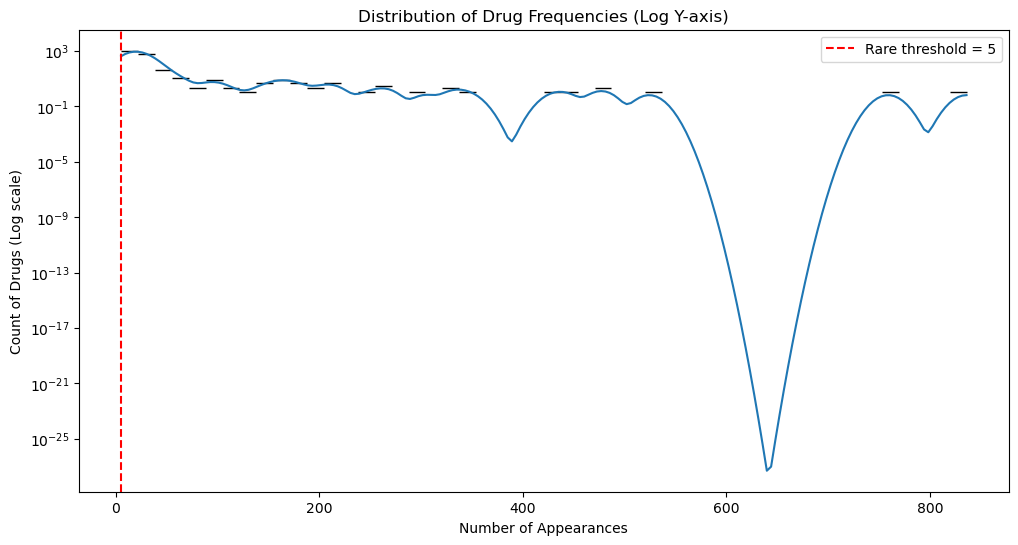

C:\Users\grace\AppData\Local\Temp\ipykernel_7000\2733202740.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_drugs, x='Frequency', y='Drug', palette='Blues_d')


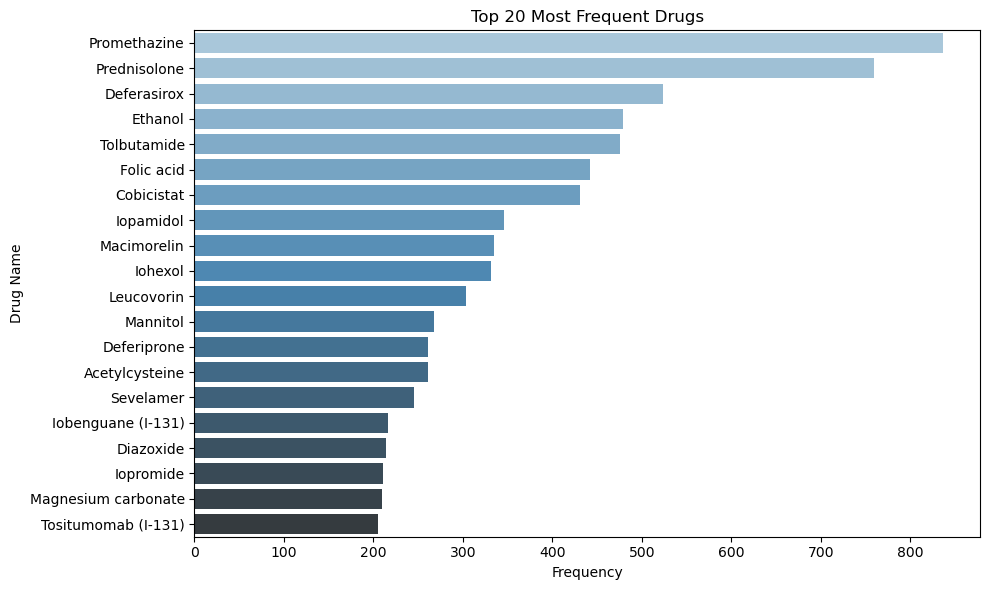

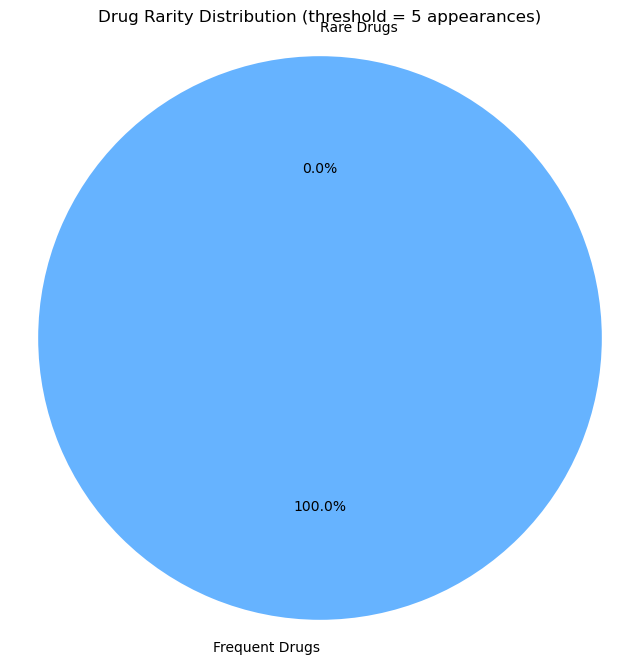


Top 30 rare drugs (lowest frequency):
Empty DataFrame
Columns: [Drug, Frequency]
Index: []


In [9]:
# ====================== VISUALIZE RARE DRUGS ======================
print("\n📊 Plotting distribution of rare drugs...")

import matplotlib.pyplot as plt
import seaborn as sns

# Count frequency of each drug (appearing in Drug_A or Drug_B)
all_drugs = pd.concat([df2['Drug_A'], df2['Drug_B']])
drug_counts = all_drugs.value_counts().reset_index()
drug_counts.columns = ['Drug', 'Frequency']

# Define rare drugs (same threshold you'll use for removal)
min_freq = 5                                      # ← Change this to match your removal threshold
rare_drugs_df = drug_counts[drug_counts['Frequency'] < min_freq]

print(f"Number of rare drugs (frequency < {min_freq}): {len(rare_drugs_df)}")

# Plot 1: Overall drug frequency distribution (log scale recommended)
plt.figure(figsize=(12, 6))
sns.histplot(drug_counts['Frequency'], bins=50, kde=True, log_scale=(False, True))
plt.title('Distribution of Drug Frequencies (Log Y-axis)')
plt.xlabel('Number of Appearances')
plt.ylabel('Count of Drugs (Log scale)')
plt.axvline(x=min_freq, color='red', linestyle='--', label=f'Rare threshold = {min_freq}')
plt.legend()
plt.show()

# Plot 2: Top 20 most frequent drugs vs. number of rare drugs
plt.figure(figsize=(10, 6))
top_drugs = drug_counts.head(20)
sns.barplot(data=top_drugs, x='Frequency', y='Drug', palette='Blues_d')
plt.title('Top 20 Most Frequent Drugs')
plt.xlabel('Frequency')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()

# Plot 3: Summary pie chart - Rare vs Non-rare drugs
labels = ['Rare Drugs', 'Frequent Drugs']
sizes = [len(rare_drugs_df), len(drug_counts) - len(rare_drugs_df)]
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title(f'Drug Rarity Distribution (threshold = {min_freq} appearances)')
plt.axis('equal')
plt.show()

# Optional: Show list of rare drugs (top 30)
print("\nTop 30 rare drugs (lowest frequency):")
print(rare_drugs_df.head(30)[['Drug', 'Frequency']])